# Community Detection in Graphs Using $k$-Means

Previously, we have seen how we can detect communities in graphs via solving the densest subgraph problem. In this active learning sessions, we will use $k$-Means clustering to identify communities in graphs.

For this active learning session, you are free to use LLMs, such as ChatGPT, to facilitate efficient coding. However, there are the following **constraints**:
- The tasks must be done sequentially. Specifically, you must not give the entire Jupyter Notebook to an LLM and you must not tell it to "solve everything". Instead, you have to go step by step and you have to understand the code and write your answers before you proceed.
- All of your observations and takeaways must be written entirely by you; the LLM may only be used for generating code.

To perform our community detection tasks we will use the following datasets:
- OpenFlights (n=3,214, m=66,771): https://networks.skewed.de/net/openflights
- MUSAE Facebook (n=22,470, m=170,823): https://snap.stanford.edu/data/facebook-large-page-page-network.html

## Basic Graph Class

We provide the basic implementation of a graph class.

Iterating over nodes can be done by using ```for u in G.nodesToEdges``` and iterating over the edges incident upon node ```u``` can be done using ```for v in G.nodesToEdges[u]```. To check whether an edge $(u,v)$ exists use ```G.edgeExists(u,v)```.

Graphs can be read from files using the ```readFromFile```-procedure. Using the optional argument ```verticesToIgnore``` which expects a ```set()``` as input, you may exclude some nodes from the graph, i.e., if ```verticesToIgnore``` is some set $S$ then it will load the graph $G=(V\setminus S,E[V\setminus S])$.  Note that you might have to delete header-rows from some data files to make the procedure work.

**Your task:** Update the implementation such that it also stores the adjacency matrix of the graph. To limit the size of the adjacency matrix to 500x500, the graph should only store the 500 vertices of highest degree.

In [5]:
import numpy as np

class Graph:
    def __init__(self):
        self.numNodes = 0
        self.numEdges = 0

        self.edges = set()
        self.nodesToEdges = {}

        # adjacency matrix data
        self.matrixNodes = []          # node at each matrix index
        self.nodeToMatrixIndex = {}    # node -> matrix index
        self.adjacencyMatrix = []      # 0/1 adjacency matrix

    def addEdge(self,u,v):
        if u == v or v in self.nodesToEdges and u in self.nodesToEdges[v]:
            return
            
        self.numEdges += 1
        self.addNeighbor(u,v)
        self.addNeighbor(v,u)
        self.edges.add((u,v)) # we only add one pair (u,v) and not (v,u)

    def removeEdge(self,u,v):
        self.numEdges -= 1
        self.nodesToEdges[u].remove(v)
        self.nodesToEdges[v].remove(u)

        if (u,v) in self.edges:
            self.edges.remove((u,v))
        else: # (v,u) in self.edges
            self.edges.remove((v,u))

    def addNeighbor(self,u,v):
        if u not in self.nodesToEdges:
            self.numNodes += 1
            self.nodesToEdges[u] = set()

        self.nodesToEdges[u].add(v)

    def edgeExists(self, u, v):
        return ((u,v) in self.edges or (v,u) in self.edges)
        
    def degree(self, u):
        return len(self.nodesToEdges[u])

    def buildAdjacencyMatrix(self, maxSize=500):
        # 1. Sort all known nodes by their degree in descending order
        sorted_nodes = sorted(self.nodesToEdges.keys(), key=self.degree, reverse=True)

        # 2. Keep only the top 'maxSize' nodes
        self.matrixNodes = sorted_nodes[:maxSize]

        # 3. Create a dictionary mapping the node ID to its index (0 to k-1) in the matrix
        self.nodeToMatrixIndex = {node: i for i, node in enumerate(self.matrixNodes)}

        k = len(self.matrixNodes)

        # 4. Initialize a k x k matrix with zeros
        # (Using standard Python lists to match the __init__ definition,
        # but np.zeros((k,k), dtype=int) could also be used here)
        self.adjacencyMatrix = [[0] * k for _ in range(k)]

        # 5. Populate the adjacency matrix
        for i, u in enumerate(self.matrixNodes):
            # Iterate through the neighbors of node u
            for v in self.nodesToEdges[u]:
                # Only add the edge to the matrix if neighbor v is ALSO in the top 500 nodes
                if v in self.nodeToMatrixIndex:
                    j = self.nodeToMatrixIndex[v]
                    self.adjacencyMatrix[i][j] = 1
                    # Note: We don't need to explicitly set self.adjacencyMatrix[j][i] = 1 here
                    # because the outer loop will eventually reach node 'v' and check 'u'.

    def readFromFile(self, filePath, separator=',', verticesToIgnore=set()):
        with open(filePath, 'r') as f:
            for line in f:
                split = line.split(separator)
                u = int(split[0])
                v = int(split[1])

                if u in verticesToIgnore or v in verticesToIgnore:
                    continue
                    
                self.addEdge(u, v)

        self.buildAdjacencyMatrix()

        print(f'Finished reading graph with {self.numNodes} nodes and {self.numEdges} edges.')

## Visualize the adjacency matrix

**Your task:** Load the two files and visualize their 500x500 adjacency matrix as a black and white grid for both datasets. In the plots, make sure that they contain the filenames. In the answer field below, write whether you can find any structure.

Finished reading graph with 3214 nodes and 18858 edges.


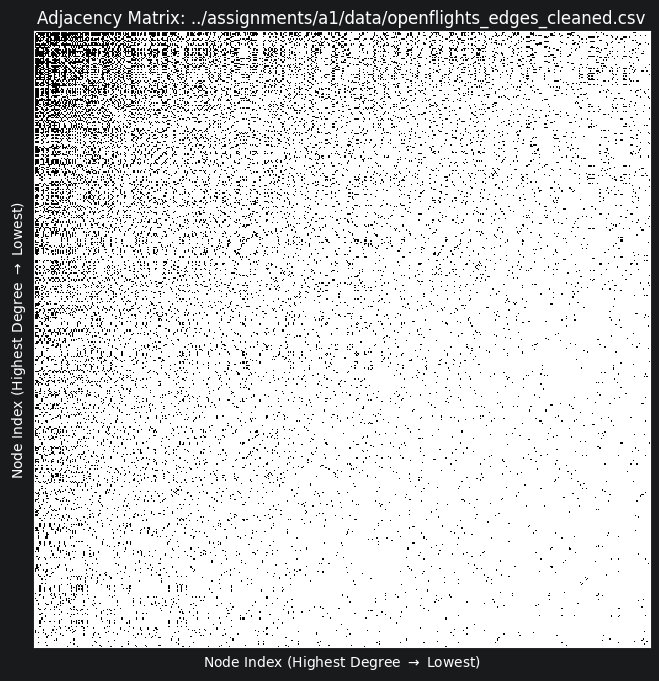

Finished reading graph with 22470 nodes and 170823 edges.


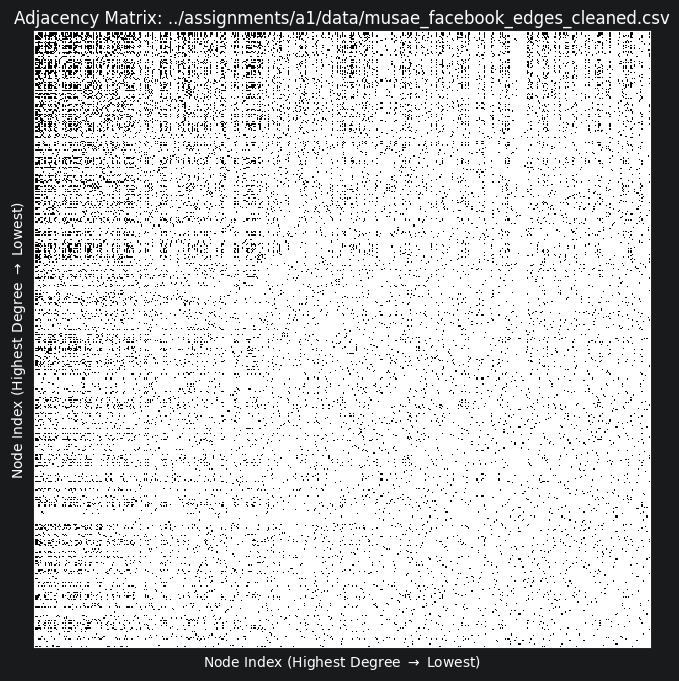

In [11]:
import matplotlib.pyplot as plt

def visualize_adjacency_matrix(file_path, separator=','):
    # Initialize the graph and read the data
    g = Graph()
    g.readFromFile(file_path, separator=separator)

    # Create the plot
    plt.figure(figsize=(8, 8))

    # imshow displays the 2D array. cmap='binary' makes 0=white and 1=black.
    plt.imshow(g.adjacencyMatrix, cmap='binary', interpolation='none')

    plt.title(f'Adjacency Matrix: {file_path}')
    plt.xlabel('Node Index (Highest Degree $\\rightarrow$ Lowest)')
    plt.ylabel('Node Index (Highest Degree $\\rightarrow$ Lowest)')

    # Add a visual grid frame for aesthetics
    plt.gca().tick_params(bottom=False, left=False, labelbottom=False, labelleft=False)
    plt.show()
    return g

# --- Run the visualization for your two files ---
# Replace the placeholder strings with your actual file names
file1 = '../assignments/a1/data/openflights_edges_cleaned.csv'
file2 = '../assignments/a1/data/musae_facebook_edges_cleaned.csv'

g1_openflights = visualize_adjacency_matrix(file1)
g2_facebook = visualize_adjacency_matrix(file2)

**Your answer:** Both seem to be symmetrical. The Openflights graph has a more dense upper left corner what means that highly connected nodes are connected to other highly connected nodes.

On the other hand the Facebook graph seems to have more of a grid pattern what makes me think that there are more circles in the relations. A group or something that follows everyone inside but not too many outside the group.
Furthermore, there are more nodes That are in the top 500 that have not many other connections in the top 500. That means that some nodes with many neighbors are connected to nodes with not that many neighbors.

## Find clusters using $k$-Means

**Your tasks:** 

Consider the rows of the adjacency matrix as points in a high-dimensional space. Do the following:
- Write a function that clusters the points using the `sklearn` implementation of Lloyd's algorithm.
- Perform the clustering for $k=3,5,10$.
- Reorder the rows of the adjacency matrix based on the clustering.
- Visualize the adjacency matrix. In the plots, make sure that they contain the filenames. Furthermore, in the visualization ensure to highlight (in a different color) the bounding boxes of the clusters.

In the answer field below, write about your findings. You should answer the following questions:
- How has the visualization changed? Specifically, answer whether you can observe any patterns and explain the patterns.
- Based on your visual inspection, which value of $k$ do you think matches the community structure best?

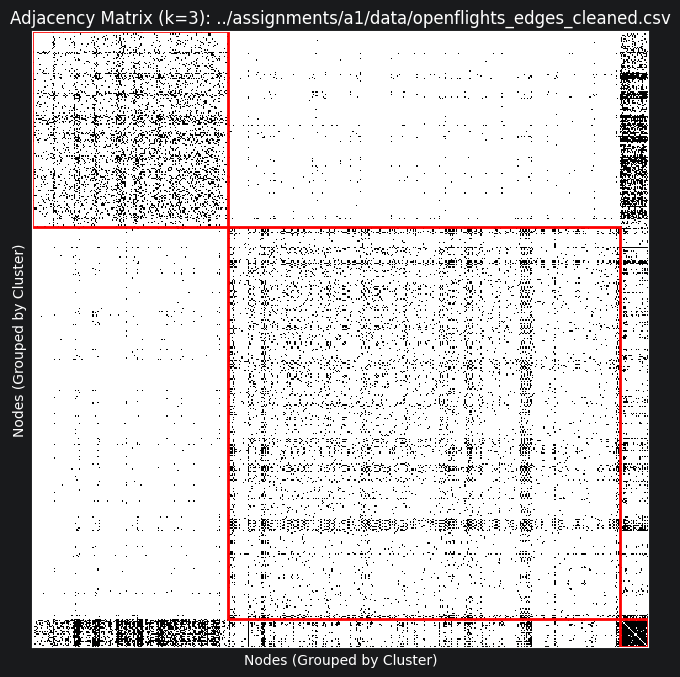

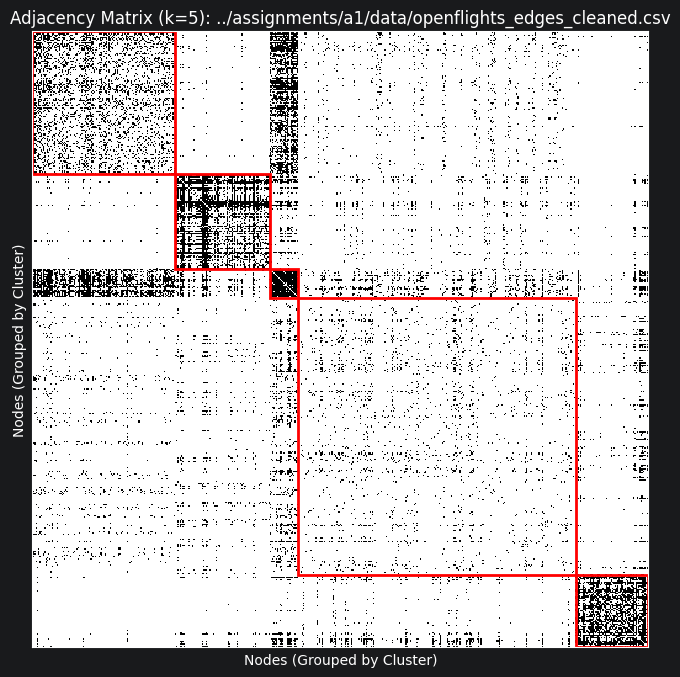

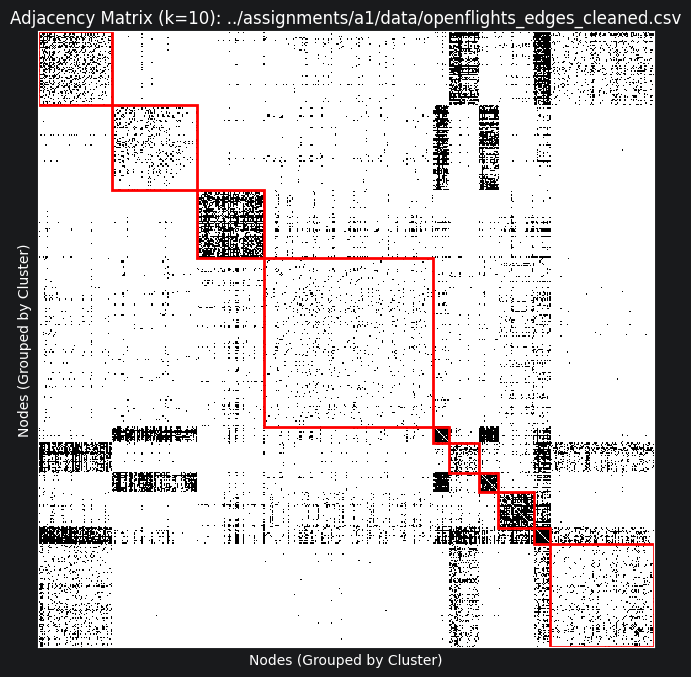

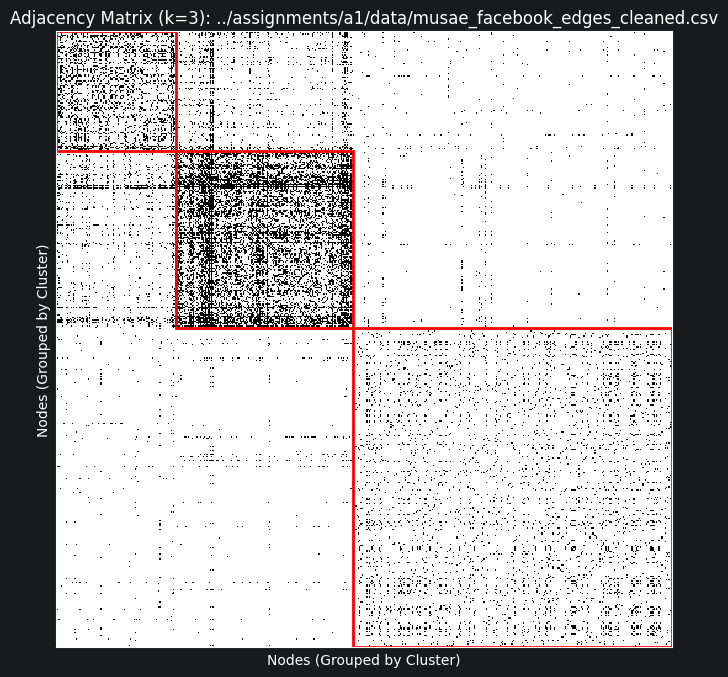

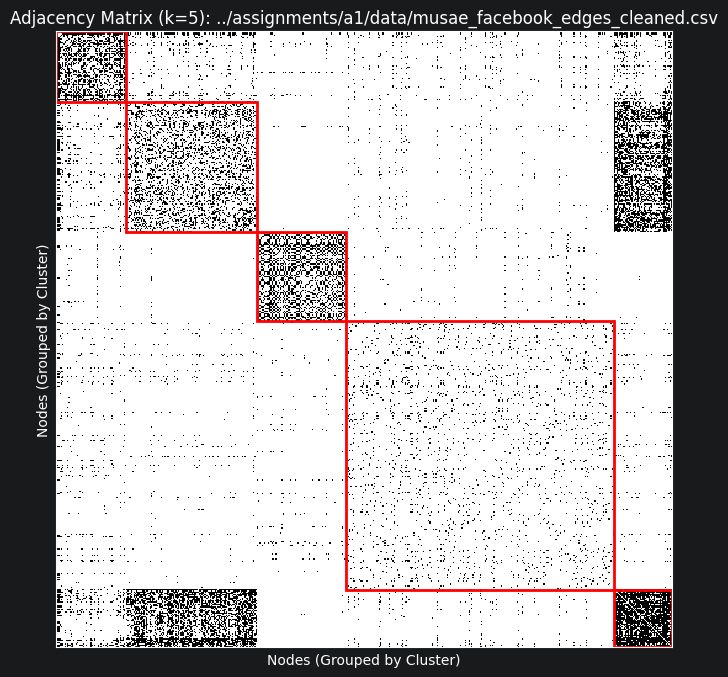

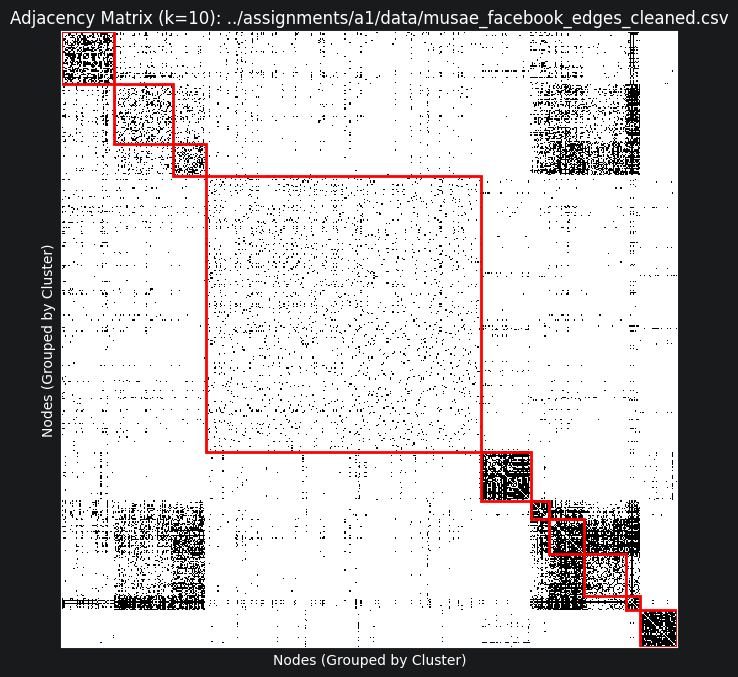

In [12]:
# fill in
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from sklearn.cluster import KMeans

def cluster_and_visualize(g, file_path, k_values=[3, 5, 10]):
    # Convert adjacency matrix to a NumPy array for easier slicing
    adj_matrix = np.array(g.adjacencyMatrix)

    for k in k_values:
        # 1. Perform k-Means clustering on the rows (node connection profiles)
        kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
        labels = kmeans.fit_predict(adj_matrix)

        # 2. Reorder the nodes based on cluster labels to group communities together
        sorted_indices = np.argsort(labels)

        # Reorder BOTH rows and columns to maintain the adjacency structure
        reordered_matrix = adj_matrix[sorted_indices, :][:, sorted_indices]

        # 3. Calculate the boundaries (sizes) of each cluster for the bounding boxes
        sorted_labels = labels[sorted_indices]
        cluster_boundaries = []
        current_label = sorted_labels[0]
        start_idx = 0

        for i in range(1, len(sorted_labels)):
            if sorted_labels[i] != current_label:
                cluster_boundaries.append((start_idx, i - start_idx)) # (start_index, size)
                current_label = sorted_labels[i]
                start_idx = i
        # Add the final cluster
        cluster_boundaries.append((start_idx, len(sorted_labels) - start_idx))

        # 4. Plot the reordered matrix
        plt.figure(figsize=(8, 8))
        plt.imshow(reordered_matrix, cmap='binary', interpolation='none')
        plt.title(f'Adjacency Matrix (k={k}): {file_path}')
        plt.xlabel('Nodes (Grouped by Cluster)')
        plt.ylabel('Nodes (Grouped by Cluster)')
        plt.gca().tick_params(bottom=False, left=False, labelbottom=False, labelleft=False)

        # 5. Draw the bounding boxes highlighting the clusters
        ax = plt.gca()
        for start, size in cluster_boundaries:
            # We subtract 0.5 to align the box with the pixel| boundaries in imshow
            rect = patches.Rectangle((start - 0.5, start - 0.5), size, size,
                                     linewidth=2, edgecolor='red', facecolor='none')
            ax.add_patch(rect)

        plt.show()

cluster_and_visualize(g1_openflights, file1)
cluster_and_visualize(g2_facebook, file2)

**Your answer:**
The first change is the sorting of the nodes is no longer the density but the cluster. In all plots we can see that the marked area is really dense except of one big area that seems way less dense then the others. That comes form the highly connected nodes being put into the same cluster and then the last cluster is just the fill up where all other nodes are put in because all nodes need to be in a cluster. Furthermore the more clusters there are the smaller the smallest cluster is.

I think that $k=5$ looks like the most promising clustering. With $k=5$ we seem to get a good mix between really small clusters (almost overfitting) and really spare clusters (with one really huge non dense cluster).

## Inspection of the clusters

**Your task:**

Now we would like to further evaluate the quality of the results. Additionally, we would like to take into account the fact that the datasets also contain the node labels. 

**Do the following without an LLM before proceeding:** Find a formal measure to evaluate how strong the cluster structure is for each cluster.

Next, do the following (you may use an LLM for this):
- Additionally load the node labels from the datasets.
- For the best value of $k$ that you have identified above, output the value of the formal measure you defined above and the node labels contained in the cluster.

In the answer field below, explain and justify the measure you chose. Furthermore, give an interpretable summary of the clusters you have found. How many of them do you think are "good" clusters with strong structure? Reflect on whether you are satisfied with the results.

In [21]:
import numpy as np
from sklearn.cluster import KMeans
from collections import Counter

def evaluate_clusters(g, labels_file, best_k, separator=','):
    # 1. Load the node labels (Assumes format: node_id, label)
    node_labels = {}
    try:
        with open(labels_file, 'r', encoding='utf-8') as f:
            for line in f:
                parts = line.strip().split(separator)
                if len(parts) >= 2:
                    try:
                        node_id = int(parts[0])
                        # Join the rest in case the label itself contains commas
                        label = separator.join(parts[1:]).strip()
                        node_labels[node_id] = label
                    except ValueError:
                        continue # Skip header rows if present
    except FileNotFoundError:
        print(f"Error: Could not find label file at {labels_file}")
        return

    # 2. Run k-Means with the chosen best k
    adj_matrix = np.array(g.adjacencyMatrix)
    kmeans = KMeans(n_clusters=best_k, random_state=42, n_init='auto')
    cluster_assignments = kmeans.fit_predict(adj_matrix)

    # Map the matrix indices back to actual Node IDs for each cluster
    clusters = {i: [] for i in range(best_k)}
    for matrix_idx, cluster_id in enumerate(cluster_assignments):
        actual_node_id = g.matrixNodes[matrix_idx]
        clusters[cluster_id].append(actual_node_id)

    # 3. Evaluate each cluster and output labels
    print(f"--- Evaluation for {labels_file} ---")
    for cluster_id, nodes in clusters.items():
        num_nodes = len(nodes)

        if num_nodes < 2:
            print(f"\nCluster {cluster_id}: Size {num_nodes} - Too small to compute density.")
            continue

        # Calculate Internal Edge Density
        internal_edges = 0
        for i in range(num_nodes):
            for j in range(i + 1, num_nodes):
                u = nodes[i]
                v = nodes[j]
                if g.edgeExists(u, v):
                    internal_edges += 1

        possible_edges = (num_nodes * (num_nodes - 1)) / 2
        density = internal_edges / possible_edges

        # Fetch labels for the nodes in this cluster
        cluster_labels = [node_labels.get(n, f"Unknown_Node_{n}") for n in nodes]
        label_counts = Counter(cluster_labels)

        print(f"\n[ Cluster {cluster_id} ] (Size: {num_nodes} nodes)")
        print(f"Formal Measure (Internal Density): {density:.4f}")
        print("Most Common Node Labels in this Cluster:")
        # Print the top 10 most common labels to look for semantic themes
        for label, count in label_counts.most_common(30):
            print(f"  - {label} ({count} nodes)")

g1_labels = '../assignments/a1/data/openflights/nodes.csv'
g2_labels = '../assignments/a1/data/facebook_large/musae_facebook_target.csv'

evaluate_clusters(g1_openflights, g1_labels, best_k=5)
print()
print()
print()
print()
evaluate_clusters(g2_facebook, g2_labels, best_k=5)

--- Evaluation for ../assignments/a1/data/openflights/nodes.csv ---

[ Cluster 0 ] (Size: 116 nodes)
Formal Measure (Internal Density): 0.2495
Most Common Node Labels in this Cluster:
  - 4029,Domodedovo International Airport,Moscow,Russia,DME,UUDD,55.40879821777344,37.90629959106445,588,3.0,N,"array([5.97861377, 1.23895702])" (1 nodes)
  - 548,London Stansted Airport,London,United Kingdom,STN,EGSS,51.8849983215,0.234999999404,348,0.0,E,"array([5.9461476 , 1.14252943])" (1 nodes)
  - 3998,Palma De Mallorca Airport,Palma de Mallorca,Spain,PMI,LEPA,39.551700592,2.73881006241,27,1.0,E,"array([5.96460986, 1.14861883])" (1 nodes)
  - 1386,Paris-Orly Airport,Paris,France,ORY,LFPO,48.7233333,2.3794444,291,1.0,E,"array([5.93998123, 1.14160973])" (1 nodes)
  - 1230,Málaga Airport,Malaga,Spain,AGP,LEMG,36.67490005493164,-4.499110221862793,53,1.0,E,"array([5.96651955, 1.15299765])" (1 nodes)
  - 2948,Pulkovo Airport,St. Petersburg,Russia,LED,ULLI,59.80030059814453,30.262500762939453,78,3.0,N,"arr

**Your answer:** (fill in)
I would use the density of the cluster to evaluate how strong the cluster structure is. Formula $\frac{2|E_c|}{|C|(|C|-1)}$. This will calculate the ration between the edges that are actually here and the maximum edges that could be there. A perfect cluster is a clique and therefore that is a good mesurement.

**Openflights**
- 1 cluster. EU flights (with some close international locations (north africa, middle east)), density of 0.249 is a ok cluster.
- 2 cluster. North American flights, density of 0.5. I would consider this a good cluster.
- 3 cluster. Another EU Cluster. 0.9407. That is a bad cluster since it only has 23 nodes and is probably overfitted.
- 4 cluster. Middle East, Asia, Austrialia, South America cluster. density 0.0401. really bad cluster since there are nodes from every continent and it is really sparse. I would assume that that cluster was just the one where non fitting nodes wher put into.
- 5 cluster. East Asia/China cluster. density 0.58. I would also consider this a good cluster all nodes are close together and seems make sense.

**Facebook**
- 1 cluster. US government sites, density 0.4536. All of the nodes in that cluster are US governmental sides
- 2 cluster. US military sites, density of 0.25. this also looks like a good cluster.
- 3 cluster. EU and European government sites. 0.4010. Also a good cluster
- 4 cluster. A bit of everything (government, companies, politicians, tvshows, ...). density 0.0466. really bad cluster since it is really mixed.
- 5 cluster. More US government sides. density 0.7965. I would consider that a good cluster too.
Over all i think the clustering on facebook dataset worked better even though we got 2 similar clusters.